### MLC-2 Lab-02/02/2026

In [1]:
import numpy as np
X=np.array([[1,2],[2,1],[3,4],[5,7],[6,8],[7,6],[8,5],[4,3]])
print(X)

[[1 2]
 [2 1]
 [3 4]
 [5 7]
 [6 8]
 [7 6]
 [8 5]
 [4 3]]


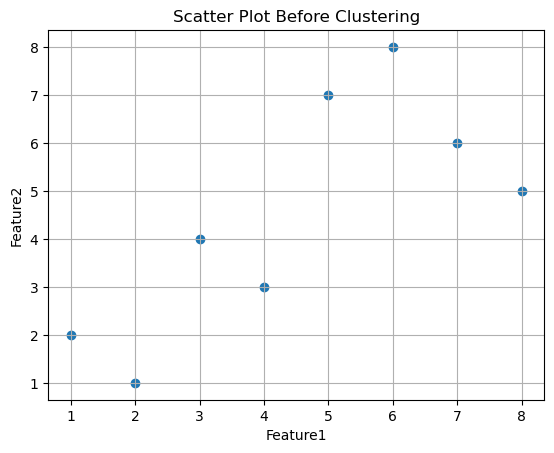

In [2]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1])
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Scatter Plot Before Clustering")
plt.grid(True)
plt.show()

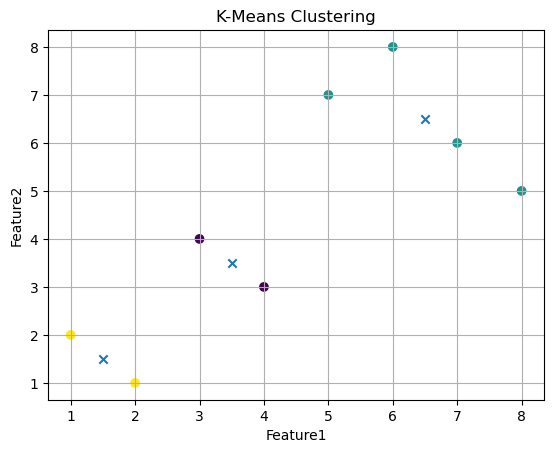

In [3]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=3,random_state=42)
labels=kmeans.fit_predict(X)
plt.scatter(X[:,0],X[:,1],c=labels)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],marker='x')
plt.title("K-Means Clustering")
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.grid(True)
plt.show()

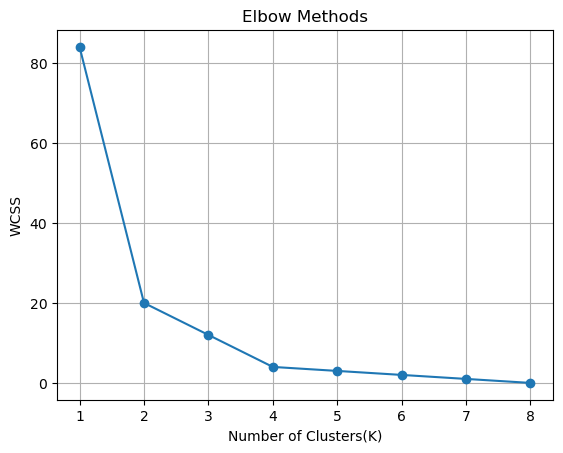

In [4]:
wcss=[]
for k in range(1,9):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)
plt.plot(range(1,9),wcss,marker='o')
plt.xlabel("Number of Clusters(K)")
plt.ylabel("WCSS")
plt.title("Elbow Methods")
plt.grid(True)
plt.show()

### MLC-2 Lab-19/02/2026

In [5]:
pip install scikit-learn-extra

Note: you may need to restart the kernel to use updated packages.


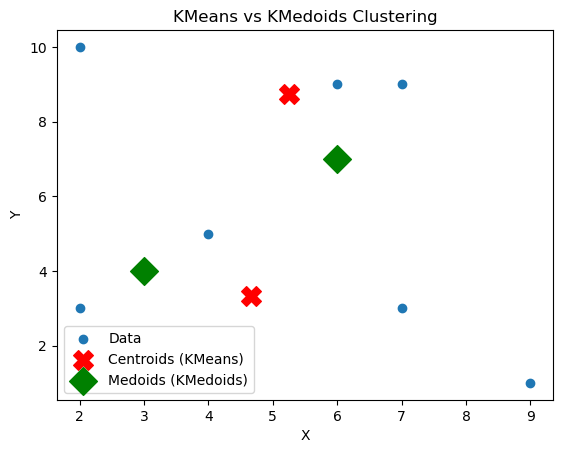

Centroids: [[4.66666667 3.33333333]
 [5.25       8.75      ]]
Medoids: [[6. 7.]
 [3. 4.]]


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
data=[[3,4],[2,3],[3,4],[4,5],[6,7],[7,3],[9,1],[2,10],[6,9],[7,9]]
df=pd.DataFrame(data,columns=['x','y'])
n_clusters=2
kmeans=KMeans(n_clusters=n_clusters,random_state=42)
kmeans.fit(df)
centroids=kmeans.cluster_centers_
kmedoids=KMedoids(n_clusters=n_clusters,random_state=42)
kmedoids.fit(df)
medoids=kmedoids.cluster_centers_
plt.scatter(df['x'],df['y'],label='Data')
plt.scatter(centroids[:,0],centroids[:,1],color='red',marker='X',s=200,label='Centroids (KMeans)')
plt.scatter(medoids[:,0],medoids[:,1],color='green',marker='D',s=200,label='Medoids (KMedoids)')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.title('KMeans vs KMedoids Clustering')
plt.show()
print("Centroids:",centroids)
print("Medoids:",medoids)

In [7]:
transactions=[("Bread","Milk","Butter","Salt"),("Bread","Milk","Egg","Apple"),("Bread","Milk","Butter","Apple"),("Egg","Butter","Apple"),("Bread","Egg","Salt"),("Bread","Milk","Tea","Apple")]
import pandas as pd
items=sorted(set(item for transaction in transactions for item in transaction))
data=[]
for transaction in transactions:
    row=[1 if item in transaction else 0 for item in items]
    data.append(row)
df=pd.DataFrame(data,columns=items)
df.index.name="Transaction"
print(df)

             Apple  Bread  Butter  Egg  Milk  Salt  Tea
Transaction                                            
0                0      1       1    0     1     1    0
1                1      1       0    1     1     0    0
2                1      1       1    0     1     0    0
3                1      0       1    1     0     0    0
4                0      1       0    1     0     1    0
5                1      1       0    0     1     0    1


In [8]:
def support(itemset, transactions):
    return sum(1 for t in transactions if set(itemset).issubset(t)) / len(transactions)

def confidence(X, Y, transactions):
    return support(set(X).union(Y), transactions) / support(X, transactions)

print("Support(Bread):", support(("Bread",), transactions))
print("Confidence (Bread → Milk):", confidence(("Bread",), ("Milk",), transactions))
print("Confidence (Bread, Milk → Egg):", confidence(("Bread","Milk"), ("Egg",), transactions))

Support(Bread): 0.8333333333333334
Confidence (Bread → Milk): 0.7999999999999999
Confidence (Bread, Milk → Egg): 0.25


In [9]:
min_support=0.5
transactions=[{"sport","tresnald"},{"sport"},{"tresnald"},{"sport","tresnald"}]
def support(itemset):
    return sum(1 for t in transactions if itemset.issubset(t))/len(transactions)
items=set().union(*transactions)
frequent_items=[{i} for i in items if support({i})>=min_support]
print("Frequent 1-itemsets:")
for i in frequent_items:
    print(i,"Support:",support(i))

Frequent 1-itemsets:
{'sport'} Support: 0.75
{'tresnald'} Support: 0.75


### MLC-2 Lab-24/02/2026

In [10]:
import math
def threshold(x,theta=0.5):
    return 1 if x>=theta else 0
def relu(x):
    return max(0,x)
def sigmoid(x, k=1):
    return 2/(1+math.exp(-k*x))
def bipolar_sigmoid(x):
    return 2/(1+math.exp(-x))-1
def tanh_n(x):
    return math.tanh(x)
def step(x):
    return 1 if x>=0 else 0
values=[-2,-1,0,0.5,1,2]
print("Input Values: ",values)
print("\n--- Identity Function ---")
for v in values:
    print(v,"->",relu(v))
print("\n--- Step Function ---")
for v in values:
    print(v,"->",step(v))
print("\n--- Threshold Function (Theta=0.5)---")
for v in values:
    print(v,"->",threshold(v))
print("\n--- Sigmoid Function ---")
for v in values:
    print(v,"->",sigmoid(v))
print("\n--- Bipolar Sigmoid Function ---")
for v in values:
    print(v,"->",bipolar_sigmoid(v))
print("\n--- Tangent Function ---")
for v in values:
    print(v,"->",tanh_n(v))

Input Values:  [-2, -1, 0, 0.5, 1, 2]

--- Identity Function ---
-2 -> 0
-1 -> 0
0 -> 0
0.5 -> 0.5
1 -> 1
2 -> 2

--- Step Function ---
-2 -> 0
-1 -> 0
0 -> 1
0.5 -> 1
1 -> 1
2 -> 1

--- Threshold Function (Theta=0.5)---
-2 -> 0
-1 -> 0
0 -> 0
0.5 -> 1
1 -> 1
2 -> 1

--- Sigmoid Function ---
-2 -> 0.2384058440442351
-1 -> 0.5378828427399902
0 -> 1.0
0.5 -> 1.2449186624037092
1 -> 1.4621171572600098
2 -> 1.7615941559557646

--- Bipolar Sigmoid Function ---
-2 -> -0.7615941559557649
-1 -> -0.4621171572600098
0 -> 0.0
0.5 -> 0.2449186624037092
1 -> 0.4621171572600098
2 -> 0.7615941559557646

--- Tangent Function ---
-2 -> -0.9640275800758169
-1 -> -0.7615941559557649
0 -> 0.0
0.5 -> 0.46211715726000974
1 -> 0.7615941559557649
2 -> 0.9640275800758169


#### McCulloch Pitts Neuron (OR Logic Example)

In [11]:
def mcp_neuron(x1,x2,w1=1,w2=1,threshold=1):
    y_sum=x1*w1+x2*w2
    return 1 if y_sum>=threshold else 0
for x1 in [0,1]:
    for x2 in [0,1]:
        print(x1,x2,"->",mcp_neuron(x1,x2))

0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [12]:
import numpy as np
class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs
    def activation(self, x):
        return 1 if x >= 0 else -1
    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        for _ in range(self.epochs):
            for i in range(len(X)):
                linear = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear)
                update = self.lr * (y[i] - y_pred)
                self.weights += update * X[i]
                self.bias += update
    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return self.activation(linear)
X = np.array([[2, 3], [1, 1], [2, 1], [-1, -2]])
y = np.array([1, 1, -1, -1])
p=Perceptron()
p.fit(X,y)
print("Prediction: ",p.predict(np.array([2,2])))

Prediction:  1


In [13]:
import numpy as np
class Adaline:
    def __init__(self, lr=0.01, epochs=20):
        self.lr = lr
        self.epochs = epochs
    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0
        for _ in range(self.epochs):
            for i in range(len(X)):
                y_sum = np.dot(X[i], self.weights) + self.bias
                error = y[i] - y_sum
                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error
    def predict(self, X):
        y_sum = np.dot(X, self.weights) + self.bias
        return np.where(y_sum >= 0, 1, -1)
X = np.array([[1, 2], [2, 3], [3, 4], [-1, -2]])
y = np.array([1, 1, -1, -1])
p=Adaline()
p.fit(X,y)
print("Prediction:",p.predict(np.array([2,2])))

Prediction: -1


### MLC-2 Lab-26/02/2026

In [14]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
X,y=make_classification(n_samples=200,n_features=2,n_redundant=0,n_clusters_per_class=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)
model=Perceptron(max_iter=1000,eta0=0.1)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.8166666666666667


In [15]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
X,y=make_classification(n_samples=300,n_features=4,n_informative=4,n_redundant=0,n_clusters_per_class=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)
model=MLPClassifier(hidden_layer_sizes=(10,5),activation='relu',learning_rate_init=0.01,max_iter=500)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 0.9111111111111111


#### Back Propogation (Manual Implementation)
#### Aim: Implementation basic Back Propogation using Numpy 

In [16]:
# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Initialize weights
np.random.seed(1)
weights = np.random.rand (2,1)
learning_rate=0.1

# Sigmoid function
def sigmoid(x):
    return 1  / (1+ np.exp(-x))
    
def sigmoid_derivative(x):
    return x * (1-x)

# Training

for epoach in range(5000):
    # Forward
    output = sigmoid(np.dot(X,weights))
    
    # Error
    error = y- output
    
    # Backward
    adjustments = learning_rate * np.dot(X.T,error * sigmoid_derivative(output))
    weights=adjustments
print("Final Output:")
print(output)

Final Output:
[[0.5]
 [0.5]
 [0.5]
 [0.5]]


In [17]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score
X,y=make_classification(n_samples=300,n_features=2,n_redundant=0,n_clusters_per_class=1)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3)
model=MLPClassifier(hidden_layer_sizes=(64,32,10),activation='relu',learning_rate_init=0.01,max_iter=500)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))

Accuracy: 1.0


### MLC Lab-19/03/2026

Minor Assignment Chapter-11

In [18]:
import numpy as np
from sklearn.decomposition import FastICA
S=np.array([[2,1],[3,-2],[1,1],[5,-2]])
A=np.array([[2,1],[1,3]])
X=S.dot(A)
print("Mixed Signals X:\n",X)
ica=FastICA(n_components=2,random_state=0)
S_rec=ica.fit_transform(X)
print("\nRecovered Signals:\n",S_rec)
corr=np.corrcoef(S_rec.T,S.T)[:2,2:]
print("\nCorrelation With Original:\n",corr)

Mixed Signals X:
 [[ 5  5]
 [ 4 -3]
 [ 3  4]
 [ 8 -1]]

Recovered Signals:
 [[-1.00000014  0.63245532]
 [ 1.00000027 -1.26491085]
 [-0.99999986 -0.63245575]
 [ 0.99999973  1.26491128]]

Correlation With Original:
 [[ 8.45154141e-01 -1.00000000e+00]
 [ 5.34522664e-01 -2.13661518e-07]]


In [19]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [20]:
pip uninstall tensorflow -y

Found existing installation: tensorflow 2.21.0
Uninstalling tensorflow-2.21.0:
  Successfully uninstalled tensorflow-2.21.0
Note: you may need to restart the kernel to use updated packages.


In [21]:
pip uninstall keras -y

Found existing installation: keras 3.13.2
Uninstalling keras-3.13.2:
  Successfully uninstalled keras-3.13.2
Note: you may need to restart the kernel to use updated packages.


In [22]:
pip install tensorflow

  Using cached tensorflow-2.21.0-cp313-cp313-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
Using cached tensorflow-2.21.0-cp313-cp313-manylinux_2_27_x86_64.whl (572.9 MB)
Using cached keras-3.13.2-py3-none-any.whl (1.5 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [tensorflow]2 [tensorflow]
Note: you may need to restart the kernel to use updated packages.


In [23]:
#!pip install tensorflow
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
X=np.array([[2,3,4,5,6],
            [3,4,5,6,7],
            [4,5,6,7,8],
            [5,6,7,8,9]],dtype=float)
inp=Input(shape=(5,))
encoded=Dense(3,activation='relu')(inp)
decoded=Dense(5,activation='linear')(encoded)
autoencoder=Model(inp,decoded)
encoder=Model(inp,encoded)
autoencoder.compile(optimizer='adam',loss='mse')
autoencoder.fit(X,X,epochs=500,verbose=0)
recon=autoencoder.predict(X)
print("Reconstruction:\n",recon)
compressed=encoder.predict(X)
print("\nCompressed (3-D) codes:\n",compressed)

I0000 00:00:1774861475.265841   36133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774861475.417753   36133 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774861475.542538   36133 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774861479.463837   36133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
Reconstruction:
 [[2.6821144 3.644871  4.3128977 4.464981  4.7842846]
 [3.2534928 4.2792516 4.810221  5.785485  6.321519 ]
 [3.8248708 4.9136314 5.307544  7.1059885 7.8587523]
 [4.39625   5.548012  5.804866  8.426494  9.3959875]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

Compressed (3-D) codes:
 [[12.137076   4.288076   9.884401 ]
 [14.023141   4.4725633 12.136525 ]
 [15.909204   4.65705   14.388648 ]
 [17.795267   4.8415375 16.640774 ]]


In [24]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
X,y=make_classification(n_samples=150,n_features=3,n_informative=3,n_redundant=0,random_state=42)
np.random.seed(0)
labeled_idx=np.random.choice(len(X),15,replace=False)
unlabeled_idx=[i for i in range(len(X)) if i not in labeled_idx]
for it in range(1,11):
    model=LogisticRegression(solver='lbfgs')
    model.fit(X[labeled_idx],y[labeled_idx])
    probs=model.predict_proba(X[unlabeled_idx])[:,1]
    uncertainty=np.abs(probs-0.5)
    query_idx=unlabeled_idx[np.argmin(uncertainty)]
    labeled_idx=np.append(labeled_idx,query_idx)
    unlabeled_idx.remove(query_idx)
    print(f"Iteration {it}: labeled set size = {len(labeled_idx)}")

Iteration 1: labeled set size = 16
Iteration 2: labeled set size = 17
Iteration 3: labeled set size = 18
Iteration 4: labeled set size = 19
Iteration 5: labeled set size = 20
Iteration 6: labeled set size = 21
Iteration 7: labeled set size = 22
Iteration 8: labeled set size = 23
Iteration 9: labeled set size = 24
Iteration 10: labeled set size = 25


In [25]:
import numpy as np
X=np.array([1,2,3,5,6],dtype=float)
y=np.array([0,0,1,1,1],dtype=float)
centers=np.array([2.0,5.0])
sigma=1.5
def rbf(x,c): return np.exp(-(x-c)**2/(2*sigma**2))
Phi=np.column_stack([rbf(X,c) for c in centers])
print("Hidden matrix Φ:\n",Phi)
w=np.linalg.pinv(Phi).dot(y)
print("\nWeights:",w)
y_pred=Phi.dot(w)
print("\nPredicted outputs:",y_pred)
labels=(y_pred>=0.5).astype(int)
print("Class labels:",labels)

Hidden matrix Φ:
 [[0.8007374  0.0285655 ]
 [1.         0.13533528]
 [0.8007374  0.41111229]
 [0.13533528 1.        ]
 [0.0285655  0.8007374 ]]

Weights: [0.0887454  1.17778653]

Predicted outputs: [0.10470582 0.24814147 0.55526428 1.18979691 0.94563278]
Class labels: [0 0 1 1 1]


In [26]:
data = {
    1: {'A','B','C'},
    2: {'A','C'},
    3: {'B','C'},
    4: {'A','B'},
    5: {'A','C'}
}
tid = {}
for tid_num, items in data.items():
    for it in items:
        tid.setdefault(it, set()).add(tid_num)
print("TID lists:")
for k,v in tid.items():
    print(k, v)
from itertools import combinations
pairs = [('A','B'), ('A','C'), ('B','C')]
print("\nSupport:")
for a,b in pairs:
    sup = len(tid[a] & tid[b])
    print(f"{a}{b}:", sup)
min_sup = 2
freq_items = {it: s for it,s in tid.items() if len(s) >= min_sup}
freq_pairs = {(a,b): len(tid[a] & tid[b]) 
              for a,b in combinations(freq_items,2) if len(tid[a] & tid[b]) >= min_sup}
print("\nFrequent 1-item:", freq_items)
print("Frequent 2-item:", freq_pairs)

TID lists:
C {1, 2, 3, 5}
A {1, 2, 4, 5}
B {1, 3, 4}

Support:
AB: 2
AC: 3
BC: 2

Frequent 1-item: {'C': {1, 2, 3, 5}, 'A': {1, 2, 4, 5}, 'B': {1, 3, 4}}
Frequent 2-item: {('C', 'A'): 3, ('C', 'B'): 2, ('A', 'B'): 2}


In [27]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
X, y = make_classification(n_samples=60, n_features=6, n_informative=4, n_redundant=0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=30, random_state=0)
bag.fit(X_train, y_train)
y_pred = bag.predict(X_test)
print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.8333333333333334


In [28]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
ada = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2), n_estimators=60, random_state=0)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
acc_ada = accuracy_score(y_test, y_pred_ada)
print("AdaBoost test accuracy:", acc_ada)
y_pred_bag = bag.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)
print("Bagging test accuracy:", acc_bag)

AdaBoost test accuracy: 0.8333333333333334
Bagging test accuracy: 0.8333333333333334


In [29]:
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(n_estimators=60,max_depth=2,random_state=0)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)
print("Gradient Boosting test accuracy:", acc_gb)

Gradient Boosting test accuracy: 0.8888888888888888


In [30]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
X, y = make_regression(n_samples=250, n_features=9, noise=10.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)
en = ElasticNet(alpha=0.5, l1_ratio=0.7, random_state=0)
en.fit(X_train, y_train)
y_pred = en.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Test MSE:", mse)

Test MSE: 668.6646050316058


### MLC Lab-30/03/2026

Gymnasium Package Use

In [31]:
!pip install gymnasium

In [32]:
# Basic Reinforcement
import numpy as np
import gymnasium as gym
class SimpleAgent:
    def __init__(self,n_states,n_actions):
        self.q_table=np.zeros((n_states,n_actions))
        self.alpha=0.1
        self.gamma=0.9
        self.epsilon=0.1
    def choose_action(self,state):
        if np.random.rand()<self.epsilon:
            return np.random.choice(len(self.q_table(state)))
        else:
            return np.argmax(self.q_table[state])
    def update(self,state,action,reward,next_state):
        best_next=np.max(self.q_table[next_state])
        self.q_table[state,action]+=self.alpha*(reward+self.gamma*best_next-self.q_table[state,action])
print("\n==== BASIC AGENT TEST ====")
agent=SimpleAgent(3,2)
agent.update(0,1,10,2)
print("Q-Table:\n",agent.q_table)


==== BASIC AGENT TEST ====
Q-Table:
 [[0. 1.]
 [0. 0.]
 [0. 0.]]


In [33]:
## Markov Decision Process (MDP Representation)
states=[0,1,2]
actions=[0,1]
P={
    0:{0:[(1,1.0)],1:[(2,1.0)]},
    1:{0:[(1,1.0)],1:[(2,1.0)]},
    2:{0:[(1,1.0)],1:[(2,1.0)]}
}
R={
    0:{0:5,1:10},
    1:{0:-1,1:2},
    2:{0:0,1:0}
}
print("\n==== MDP STRUCTURE ====")
print("States:",states)
print("Actions:",actions)
print("Transitions:",P)
print("Rewards:",R)


==== MDP STRUCTURE ====
States: [0, 1, 2]
Actions: [0, 1]
Transitions: {0: {0: [(1, 1.0)], 1: [(2, 1.0)]}, 1: {0: [(1, 1.0)], 1: [(2, 1.0)]}, 2: {0: [(1, 1.0)], 1: [(2, 1.0)]}}
Rewards: {0: {0: 5, 1: 10}, 1: {0: -1, 1: 2}, 2: {0: 0, 1: 0}}


In [40]:
## Policy Evaluation (Iterative)
import numpy as np
def policy_evaluation(policy, P,R,gamma=0.9,theta=1e-5):
    V=np.zeros(len(policy))
    ## Iteration process will run till the convergence meets (No new modification meets)
    while True:
        delta=0
        for s in range(len(policy)):
            v=V[s]
            a=policy[s]
            V[s] = R[s][a] + gamma * sum(
                prob * V[next_state] 
                for next_state, prob in P[s][a]
            )
            delta=max(delta,abs(v-V[s]))
        if delta<theta:
            break
    return V
policy=[0,1,0]
V=policy_evaluation(policy,P,R)
print("\n==== POLICY EVALUATION ====")
for i,v in enumerate(V):
    print(f"State {i} {v:.4f}")
print("\nValue Function:",V)


==== POLICY EVALUATION ====
State 0 14.4736
State 1 10.5263
State 2 9.4737

Value Function: [14.47364644 10.5262818   9.47365362]


### MLC Lab-02/04/2026

In [1]:
# Markov Decision Process (MDP Representation)
states = [0, 1, 2]
actions = [0, 1]
P = {
    0: {0: [(1, 1.0)], 1: [(2, 1.0)]},
    1: {0: [(0, 1.0)], 1: [(2, 1.0)]},
    2: {0: [(2, 1.0)], 1: [(0, 1.0)]}
}
R = {
    0: {0: 5, 1: 10},
    1: {0: -1, 1: 2},
    2: {0: 0, 1: 0}
}
print("\n===== MDP STRUCTURE =====")
print("States:", states)
print("Actions:", actions)
print("Transitions:", P)
print("Rewards:", R)


===== MDP STRUCTURE =====
States: [0, 1, 2]
Actions: [0, 1]
Transitions: {0: {0: [(1, 1.0)], 1: [(2, 1.0)]}, 1: {0: [(0, 1.0)], 1: [(2, 1.0)]}, 2: {0: [(2, 1.0)], 1: [(0, 1.0)]}}
Rewards: {0: {0: 5, 1: 10}, 1: {0: -1, 1: 2}, 2: {0: 0, 1: 0}}


In [2]:
## Policy Evaluation (Iterative)
import numpy as np
def policy_evaluation(policy, P,R,gamma=0.9,theta=1e-5):
    V=np.zeros(len(policy))
    ## Iteration process will run till the convergence meets (No new modification meets)
    while True:
        delta=0
        for s in range(len(policy)):
            v=V[s]
            a=policy[s]
            V[s] = R[s][a] + gamma * sum(
                prob * V[next_state] 
                for next_state, prob in P[s][a]
            )
            delta=max(delta,abs(v-V[s]))
        if delta<theta:
            break
    return V
policy=[0,1,0]
V=policy_evaluation(policy,P,R)
print("\n==== POLICY EVALUATION ====")
for i,v in enumerate(V):
    print(f"State {i} {v:.4f}")
print("\nValue Function:",V)


==== POLICY EVALUATION ====
State 0 6.8000
State 1 2.0000
State 2 0.0000

Value Function: [6.8 2.  0. ]


In [3]:
# Policy Improvement
def policy_improvement(V, P, R, gamma=0.9):
    policy = np.zeros(len(V), dtype=int)
    for s in range(len(V)):
        action_values = []
        for a in P[s]:
            val = R[s][a] + gamma * sum(
                prob * V[next_state] for next_state, prob in P[s][a]
            )
            action_values.append(val)
        policy[s] = np.argmax(action_values)
    return policy

improved_policy = policy_improvement(V, P, R)

print("\n===== POLICY IMPROVEMENT =====")
print("Improved Policy:", improved_policy)


===== POLICY IMPROVEMENT =====
Improved Policy: [1 0 1]


In [4]:
# Policy Iteration
def policy_iteration(P, R, gamma=0.9):
    policy = np.zeros(len(P), dtype=int)
    while True:
        V = policy_evaluation(policy, P, R, gamma)
        new_policy = policy_improvement(V, P, R, gamma)
        if np.array_equal(policy, new_policy):
            break
        policy = new_policy
    return policy, V

opt_policy, opt_V = policy_iteration(P, R)

print("\n===== POLICY ITERATION =====")
print("Optimal Policy:", opt_policy)
print("Optimal Value:", opt_V)


===== POLICY ITERATION =====
Optimal Policy: [1 0 1]
Optimal Value: [52.63154007 46.36838606 47.36838606]


In [5]:
import numpy as np
def value_iteration(P, R, gamma=0.9, theta=1e-10):
    V = np.zeros(len(P))
    while True:
        delta = 0
        for s in range(len(P)):
            v = V[s]
            V[s] = max(
                R[s][a] + gamma * sum(
                    prob * V[next_state] for next_state, prob in P[s][a]
                )
                for a in P[s]
            )
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break
    return V
V_opt = value_iteration(P, R)
print("\n------- VALUE ITERATION -------")
print("Optimal Values:", V_opt)


------- VALUE ITERATION -------
Optimal Values: [52.63157895 46.36842105 47.36842105]
